# Chatbot with tools

### Following sections are same as 1_basic_chatbot.ipynb

In [17]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [18]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State);

In [19]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [20]:
from langchain_groq import ChatGroq

groq_api_key=os.getenv("GROQ_API_KEY")
groq_model_name=os.getenv("GROQ_MODEL_NAME")
llm=ChatGroq(groq_api_key=groq_api_key,model_name=groq_model_name)

## Chatbot with tools

### Code for Tools usage starts from here

In [22]:
from langchain_tavily import TavilySearch

tool=TavilySearch(api_key=os.getenv("TAVILY_API_KEY"), max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API [...] ## Building a Simple Chatbot with LangGraph\n\nLangGraph makes it easy to build structured, stateful applications like chatbots. In this example we’ll learn how to create a bas

In [31]:
def multiply(a: int, b: int) -> int:
    """
    Multiplies two integers and returns the result.

    Args :
        a(int): The first integer to multiply.
    b(int): The second integer to multiply.

    Returns : 
        int: The product of the two integers.
    """
    return a * b

In [33]:
# Creating list of tools
tools=[tool,multiply]

In [34]:
# Binding tools with LLM
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

# you can see all the tools that are binded with llm in the following output

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000214071C68D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002140707B5C0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search 

In [35]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
## Add nodes
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

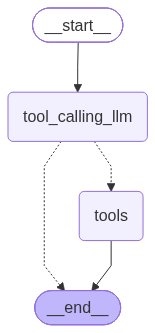

In [36]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [28]:
response=graph.invoke({"messages": "What is the latest AI news?"})
response

{'messages': [HumanMessage(content='What is the latest AI news?', additional_kwargs={}, response_metadata={}, id='b6ade1ba-cda7-40ab-86ad-e18f373bd2b4'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'p0mk6w84k', 'function': {'arguments': '{"query":"latest AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1820, 'total_tokens': 1851, 'completion_time': 0.088683335, 'completion_tokens_details': None, 'prompt_time': 0.096828303, 'prompt_tokens_details': None, 'queue_time': 0.163418565, 'total_time': 0.185511638}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc640-d4c2-7c43-9b44-0f3e94e35396-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'latest AI news', 'time_range': 'day', 'topic': '

In [29]:
# So, we can see AI message does't have any content(i.e. content is ''). But we have content in ToolMessage, which is also the last item in the graph. So we can print the Toolmessgae content same as we were printing earlier
response["messages"][-1].content

'{"query": "latest AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://simplywall.st/stocks/us/tech/nasdaq-wdc/western-digital/news/is-aidriven-hyperscale-storage-demand-reshaping-the-investme", "title": "Is AI‑Driven Hyperscale Storage Demand Reshaping the Investment Case for Western Digital (WDC)?", "content": "Before this AI news, the most optimistic analysts were already assuming Western Digital could lift earnings to about US$11.5 billion by 2029, even while warning that growing buyer concentration might squeeze margins, so this latest demand surprise could either reinforce those bold views or prompt you to reconsider how much risk you are willing to take on a story that not everyone sees the same way.", "score": 0.6439794, "published_date": "Sun, 02 Aug 2026 15:00:00 GMT", "raw_content": null}, {"url": "https://www.qatar-tribune.com/article/247011/latest-news/qatar-university-builds-integrated-ai-ecosystem-to-drive-digital-transformat

In [37]:
response=graph.invoke({"messages": "What is 2 multiplied by 3?"})
response

{'messages': [HumanMessage(content='What is 2 multiplied by 3?', additional_kwargs={}, response_metadata={}, id='748a4abc-8045-4d20-9cd2-0f1e62aa3890'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'za2cvw8sv', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1822, 'total_tokens': 1841, 'completion_time': 0.047912837, 'completion_tokens_details': None, 'prompt_time': 0.246348338, 'prompt_tokens_details': None, 'queue_time': 0.162780061, 'total_time': 0.294261175}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc643-f6c2-7160-af96-573e60344d01-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'za2cvw8sv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 18

In [38]:
# Better way to print the message 
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 3?
================================== Ai Message ==================================
Tool Calls:
  multiply (za2cvw8sv)
 Call ID: za2cvw8sv
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [40]:
response=graph.invoke({"messages": "What is 5 multiplied by 3 and then multipled by 2?"})
response

{'messages': [HumanMessage(content='What is 5 multiplied by 3 and then multipled by 2?', additional_kwargs={}, response_metadata={}, id='1fa1aac7-aa06-4de5-93c2-646718a288e7'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'emv0bjexr', 'function': {'arguments': '{"a":5,"b":3}', 'name': 'multiply'}, 'type': 'function'}, {'id': '3p7jqttr3', 'function': {'arguments': '{"a":15,"b":2}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 37, 'prompt_tokens': 1829, 'total_tokens': 1866, 'completion_time': 0.092251944, 'completion_tokens_details': None, 'prompt_time': 0.130315611, 'prompt_tokens_details': None, 'queue_time': 0.162461068, 'total_time': 0.222567555}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc646-7d28-79a2-9fd2-eb6cd13cf5ee-0', tool_calls=[{'name': 'multip

In [41]:
# So here we can see 2 ToolMessages, one for 5*3 and another for 15*2. So we can print the content of both the ToolMessages in the same way as we did earlier
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 3 and then multipled by 2?
================================== Ai Message ==================================
Tool Calls:
  multiply (emv0bjexr)
 Call ID: emv0bjexr
  Args:
    a: 5
    b: 3
  multiply (3p7jqttr3)
 Call ID: 3p7jqttr3
  Args:
    a: 15
    b: 2
================================= Tool Message =================================
Name: multiply

15
================================= Tool Message =================================
Name: multiply

30


In [43]:
response=graph.invoke({"messages": "What is recent AI news and then give me 5 multiplied by 7?"})
response

{'messages': [HumanMessage(content='What is recent AI news and then give me 5 multiplied by 7?', additional_kwargs={}, response_metadata={}, id='516fa504-5d3c-4e6a-ab60-f5987cc62975'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '09v6vk5r1', 'function': {'arguments': '{"query":"recent AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': '4jd7by2ef', 'function': {'arguments': '{"a":5,"b":7}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 1829, 'total_tokens': 1878, 'completion_time': 0.139269221, 'completion_tokens_details': None, 'prompt_time': 0.243570803, 'prompt_tokens_details': None, 'queue_time': 0.058432736, 'total_time': 0.382840024}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc663-4

In [44]:
# So here we can see 2 ToolMessages, one for recent AI new and another for 5*7. So we can print the content of both the ToolMessages in the same way as we did earlier
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent AI news and then give me 5 multiplied by 7?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (09v6vk5r1)
 Call ID: 09v6vk5r1
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (4jd7by2ef)
 Call ID: 4jd7by2ef
  Args:
    a: 5
    b: 7
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/2026/08/02/ai-model-competition-us-china.html", "title": "Op-ed: The U.S. lead over China in AI is all but gone. We need a change in national strategy", "content": "Many in the U.S. contend that we still have a lead over China in the AI race, but recent events show Washington forced to respond to China competing at the frontier with successive br

## What is happening in the above case :
LLM send both the queries to both tools simultaneously and both tools execute query and return response to the END node.

## ReAct agent :
LLM send first query to tavily tool, then tavily tool return response to the LLM, then LLM again send the request to multiply tool and multiply tool again send the response to the LLM and finally LLM send the final response to END node. 

This way of communication or this agent architecture is called ReAct architecture.
In ReAct there are 3 min key terms :
1. ACT
2. Observe
3. Reason

# ReAct Agent Architecture

In [ ]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

## Grpah
## Add nodes
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)

########### Change is here for making it ReAct architecture ##############
builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
########### Change is here for making it ReAct architecture ##############

## compile the graph
graph=builder.compile()

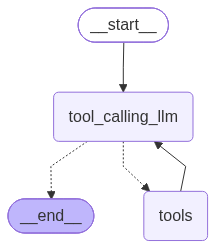

In [46]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [49]:
response=graph.invoke({"messages": "What is recent AI news and then give me 5 multiplied by 7?"})
response

{'messages': [HumanMessage(content='What is recent AI news and then give me 5 multiplied by 7?', additional_kwargs={}, response_metadata={}, id='38ff50c6-9217-4b93-a0ac-b633f12b8b86'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'bmw0d6nnz', 'function': {'arguments': '{"query":"recent AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': '4zkagbj9q', 'function': {'arguments': '{"a":5,"b":7}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 49, 'prompt_tokens': 1829, 'total_tokens': 1878, 'completion_time': 0.149055389, 'completion_tokens_details': None, 'prompt_time': 0.242721443, 'prompt_tokens_details': None, 'queue_time': 0.058333957, 'total_time': 0.391776832}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019fc698-c

#### So, here we can see final output is AIMessage and not the ToolMessage. LLM recieved the output of both tools and build a final response message.

In [51]:
# So here we can see 2 ToolMessages, one for recent AI new and another for 5*7. So we can print the content of both the ToolMessages in the same way as we did earlier
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is recent AI news and then give me 5 multiplied by 7?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (bmw0d6nnz)
 Call ID: bmw0d6nnz
  Args:
    query: recent AI news
    time_range: day
    topic: news
  multiply (4zkagbj9q)
 Call ID: 4zkagbj9q
  Args:
    a: 5
    b: 7
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.kucoin.com/news/flash/morgan-stanley-120-page-report-analyzes-ai-sector-s-recent-correction", "title": "Morgan Stanley's 120-page report analyzes the recent correction in the AI sector.", "content": "Morgan Stanley released a 120-page daily market report on July 27 titled \"Playing the AI Infrastructure Dip,\" analyzing the recent correction in the AI sec